In [ ]:
import pandas as pd

In [ ]:
raw_file=pd.ExcelFile('/content/BCG_Task1_RAW_FINANCIAL_STATEMENTS.xlsx')

In [ ]:
file_path='/content/BCG_Task1_RAW_FINANCIAL_STATEMENTS.xlsx'
df_is_2021 = pd.read_excel(file_path, sheet_name='IS_2021')
df_is_2022 = pd.read_excel(file_path, sheet_name='IS_2022')
df_is_2023 = pd.read_excel(file_path, sheet_name='IS_2023')

In [ ]:
print(f"\nColumns: {list(df_is_2021.columns)}")


Columns: ['revenue_oas', 'sales_serv_revenue_oas', 'financing_serv_revenue_oas', 'other_revenue_oas', 'cost_of_revenue_oas', 'cost_of_goods_n_serv_oas', 'cost_of_financing_serv_oas', 'other_cost_oas', 'gross_profit_oas', 'other_operating_income_oas', 'operating_expenses_oas', 'sga_expenses_oas', 'selling_marketing_expenses_oas', 'ga_expenses_oas', 'rd_expenses_oas', 'loss_on_bad_debts_oas', 'loss_on_impairment_oas', 'disposal_of_assets_loss_oas', 'other_operating_expenses_oas', 'operating_income_oas', 'non-operating_income_loss_oas', 'net_interest_expense_oas', 'interest_expense_oas', 'interest_income_oas', 'income_loss_affiliates_oas', 'income_loss_from_asso_oas', 'income_loss_from_jv_oas', 'gain_loss_on_other_inv_oas', 'gain_loss_on_change_in_fv_oas', 'gain_loss_on_fc_ex_oas', 'other_non-op_income_loss_oas', 'pretax_income_from_continu_op_oas', 'income_tax_expense_oas', 'current_income_tax_oas', 'deferred_income_tax_oas', 'income_tax_adjustments_oas', 'net_income_from_continu_op_oas

In [ ]:
print(f"\nFirst few rows:\n{df_is_2021.head()}")


First few rows:
    revenue_oas  sales_serv_revenue_oas  financing_serv_revenue_oas  \
0   53823000000             53823000000                         NaN   
1  365817000000            365817000000                         NaN   
2  168088000000            168088000000                         NaN   

   other_revenue_oas  cost_of_revenue_oas  cost_of_goods_n_serv_oas  \
0                NaN          40217000000               40217000000   
1                NaN         212981000000              212981000000   
2                NaN          52232000000               52232000000   

   cost_of_financing_serv_oas  other_cost_oas  gross_profit_oas  \
0                         NaN             NaN       13606000000   
1                         NaN             NaN      152836000000   
2                         NaN             NaN      115856000000   

   other_operating_income_oas  ...  preferred_stock_dividends_oas  \
0                  27000000.0  ...                            NaN   
1     

In [ ]:
all_data = []

# Define which sheets to load and what year they represent
sheets_info = [
    ('BS_2021', 'IS_2021', 'CF_2021', 2021),
    ('BS_2022', 'IS_2022', 'CF_2022', 2022),
    ('BS_2023', 'IS_2023', 'CF_2023', 2023),
]

for bs_sheet, is_sheet, cf_sheet, year in sheets_info:

    # Load the three statements for this year
    df_bs = pd.read_excel(file_path, sheet_name=bs_sheet)
    df_is = pd.read_excel(file_path, sheet_name=is_sheet)
    df_cf = pd.read_excel(file_path, sheet_name=cf_sheet)

    # Loop through each company (each row = one company)
    for i in range(3):

        # Map ticker to company name
        ticker = df_bs.loc[i, 'thscode']
        company_map = {'TSLA.O': 'Tesla', 'AAPL.O': 'Apple', 'MSFT.O': 'Microsoft'}
        company = company_map[ticker]

        # Extract the 5 metrics
        row = {
            'Company': company,
            'Year': year,
            'Total Revenue': df_is.loc[i, 'revenue_oas'],
            'Net Income': df_is.loc[i, 'net_income_oas'],
            'Total Assets': df_bs.loc[i, 'total_assets_oas'],
            'Total Liabilities': df_bs.loc[i, 'total_liabilities_oas'],
            'Cash Flow from Operations': df_cf.loc[i, 'net_cash_flows_from_oa_oas']
        }

        all_data.append(row)

# Combine all rows into one DataFrame
df_clean = pd.DataFrame(all_data)

# Sort by Company, then Year (important for growth calculations later!)
df_clean = df_clean.sort_values(['Company', 'Year']).reset_index(drop=True)

print(df_clean)

     Company  Year  Total Revenue   Net Income  Total Assets  \
0      Apple  2021   365817000000  94680000000  351002000000   
1      Apple  2022   394328000000  99803000000  352755000000   
2      Apple  2023   383285000000  96995000000  352583000000   
3  Microsoft  2021   168088000000  61271000000  333779000000   
4  Microsoft  2022   198270000000  72738000000  364840000000   
5  Microsoft  2023   211915000000  72361000000  411976000000   
6      Tesla  2021    53823000000   5644000000   62131000000   
7      Tesla  2022    81462000000  12587000000   82338000000   
8      Tesla  2023    96773000000  14974000000  106618000000   

   Total Liabilities  Cash Flow from Operations  
0       287912000000               104038000000  
1       302083000000               122151000000  
2       290437000000               110543000000  
3       191791000000                76740000000  
4       198298000000                89035000000  
5       205753000000                87582000000  
6        

In [ ]:
import numpy as np

df = df_clean.copy()

# List of columns that are financial values (in raw USD)
money_cols = ['Total Revenue', 'Net Income', 'Total Assets',
              'Total Liabilities', 'Cash Flow from Operations']

# Divide each by 1,000,000 to get millions
for col in money_cols:
    df[col] = df[col] / 1_000_000  # The underscore is just for readability (Python 3.6+)

print("=== AFTER CONVERTING TO MILLIONS ===")
print(df)


=== AFTER CONVERTING TO MILLIONS ===
     Company  Year  Total Revenue  Net Income  Total Assets  \
0      Apple  2021       365817.0     94680.0      351002.0   
1      Apple  2022       394328.0     99803.0      352755.0   
2      Apple  2023       383285.0     96995.0      352583.0   
3  Microsoft  2021       168088.0     61271.0      333779.0   
4  Microsoft  2022       198270.0     72738.0      364840.0   
5  Microsoft  2023       211915.0     72361.0      411976.0   
6      Tesla  2021        53823.0      5644.0       62131.0   
7      Tesla  2022        81462.0     12587.0       82338.0   
8      Tesla  2023        96773.0     14974.0      106618.0   

   Total Liabilities  Cash Flow from Operations  
0           287912.0                   104038.0  
1           302083.0                   122151.0  
2           290437.0                   110543.0  
3           191791.0                    76740.0  
4           198298.0                    89035.0  
5           205753.0            

In [ ]:
df = df.sort_values(['Company', 'Year']).reset_index(drop=True)
print(df)

     Company  Year  Total Revenue  Net Income  Total Assets  \
0      Apple  2021       365817.0     94680.0      351002.0   
1      Apple  2022       394328.0     99803.0      352755.0   
2      Apple  2023       383285.0     96995.0      352583.0   
3  Microsoft  2021       168088.0     61271.0      333779.0   
4  Microsoft  2022       198270.0     72738.0      364840.0   
5  Microsoft  2023       211915.0     72361.0      411976.0   
6      Tesla  2021        53823.0      5644.0       62131.0   
7      Tesla  2022        81462.0     12587.0       82338.0   
8      Tesla  2023        96773.0     14974.0      106618.0   

   Total Liabilities  Cash Flow from Operations  
0           287912.0                   104038.0  
1           302083.0                   122151.0  
2           290437.0                   110543.0  
3           191791.0                    76740.0  
4           198298.0                    89035.0  
5           205753.0                    87582.0  
6            30548.

In [ ]:
df['Revenue Growth (%)'] = df.groupby('Company')['Total Revenue'].pct_change() * 100
df['Net Income Growth (%)'] = df.groupby('Company')['Net Income'].pct_change() * 100
df['Assets Growth (%)'] = df.groupby('Company')['Total Assets'].pct_change() * 100
df['Liabilities Growth (%)'] = df.groupby('Company')['Total Liabilities'].pct_change() * 100
df['Cash Flow Growth (%)'] = df.groupby('Company')['Cash Flow from Operations'].pct_change() * 100

# Replace NaN with 0 (or you could drop those rows)
df = df.fillna(0)

print("=== WITH GROWTH RATES ===")
print(df.round(2))  # Round to 2 decimal places for clean display

=== WITH GROWTH RATES ===
     Company  Year  Total Revenue  Net Income  Total Assets  \
0      Apple  2021       365817.0     94680.0      351002.0   
1      Apple  2022       394328.0     99803.0      352755.0   
2      Apple  2023       383285.0     96995.0      352583.0   
3  Microsoft  2021       168088.0     61271.0      333779.0   
4  Microsoft  2022       198270.0     72738.0      364840.0   
5  Microsoft  2023       211915.0     72361.0      411976.0   
6      Tesla  2021        53823.0      5644.0       62131.0   
7      Tesla  2022        81462.0     12587.0       82338.0   
8      Tesla  2023        96773.0     14974.0      106618.0   

   Total Liabilities  Cash Flow from Operations  Revenue Growth (%)  \
0           287912.0                   104038.0                0.00   
1           302083.0                   122151.0                7.79   
2           290437.0                   110543.0               -2.80   
3           191791.0                    76740.0            

In [ ]:
df_new = df[['Company', 'Year'] + [c for c in df.columns if 'Growth' in c]]

In [ ]:
print(df_new)

     Company  Year  Revenue Growth (%)  Net Income Growth (%)  \
0      Apple  2021            0.000000               0.000000   
1      Apple  2022            7.793788               5.410858   
2      Apple  2023           -2.800461              -2.813543   
3  Microsoft  2021            0.000000               0.000000   
4  Microsoft  2022           17.956071              18.715216   
5  Microsoft  2023            6.882030              -0.518299   
6      Tesla  2021            0.000000               0.000000   
7      Tesla  2022           51.351653             123.015592   
8      Tesla  2023           18.795267              18.964010   

   Assets Growth (%)  Liabilities Growth (%)  Cash Flow Growth (%)  
0           0.000000                0.000000              0.000000  
1           0.499427                4.921990             17.409985  
2          -0.048759               -3.855232             -9.502992  
3           0.000000                0.000000              0.000000  
4   

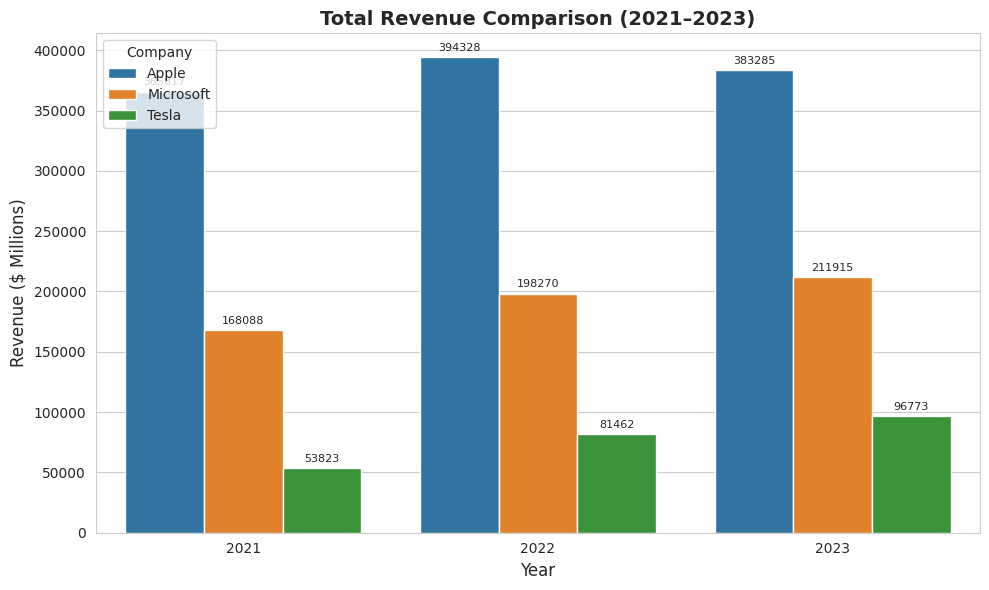

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ============================================
# CHART 1: Revenue Comparison (Bar Chart)
# ============================================

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Year', y='Total Revenue', hue='Company')

plt.title('Total Revenue Comparison (2021–2023)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Revenue ($ Millions)', fontsize=12)
plt.legend(title='Company', loc='upper left')

# Add value labels on top of bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.0f', padding=3, fontsize=8)

plt.tight_layout()
plt.show()

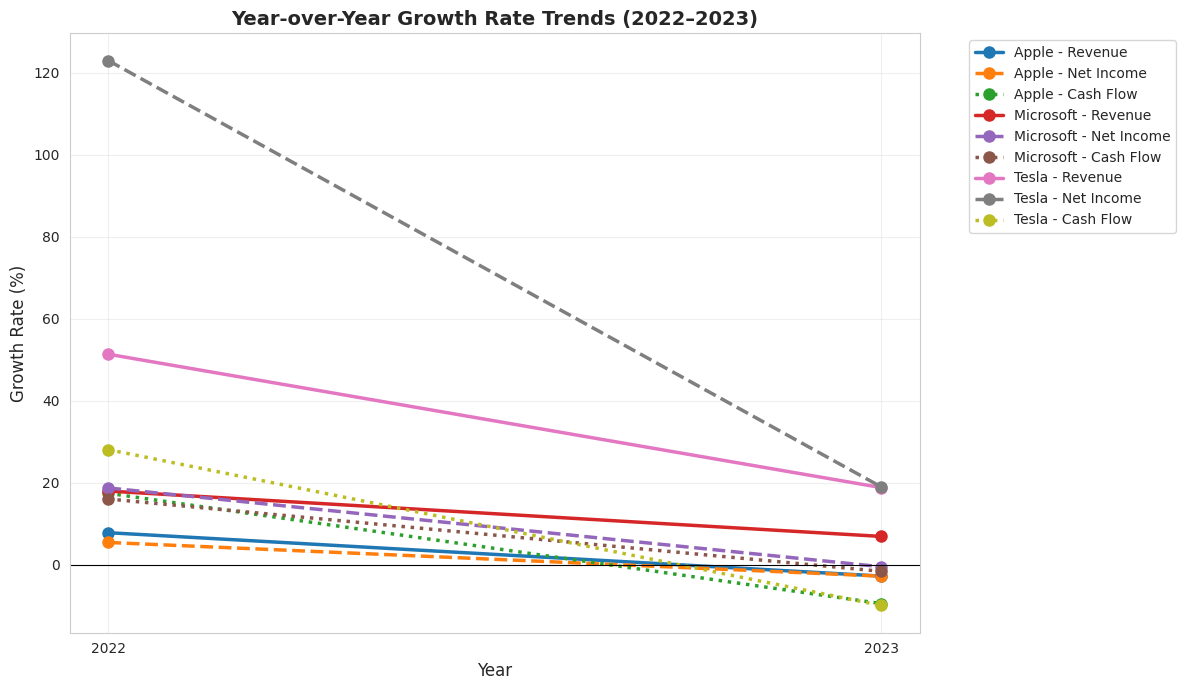

In [ ]:
df_growth = df[df['Year'] != 2021].copy()

plt.figure(figsize=(12, 7))

# Plot each metric as a separate line
metrics = ['Revenue Growth (%)', 'Net Income Growth (%)', 'Cash Flow Growth (%)']

for company in df_growth['Company'].unique():
    subset = df_growth[df_growth['Company'] == company]

    for metric in metrics:
        plt.plot(subset['Year'], subset[metric],
                 marker='o', linewidth=2.5, markersize=8,
                 label=f"{company} - {metric.replace(' Growth (%)', '')}",
                 linestyle='-' if 'Revenue' in metric else '--' if 'Net Income' in metric else ':')

plt.title('Year-over-Year Growth Rate Trends (2022–2023)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Growth Rate (%)', fontsize=12)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)  # Zero line
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Legend outside plot
plt.xticks([2022, 2023])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

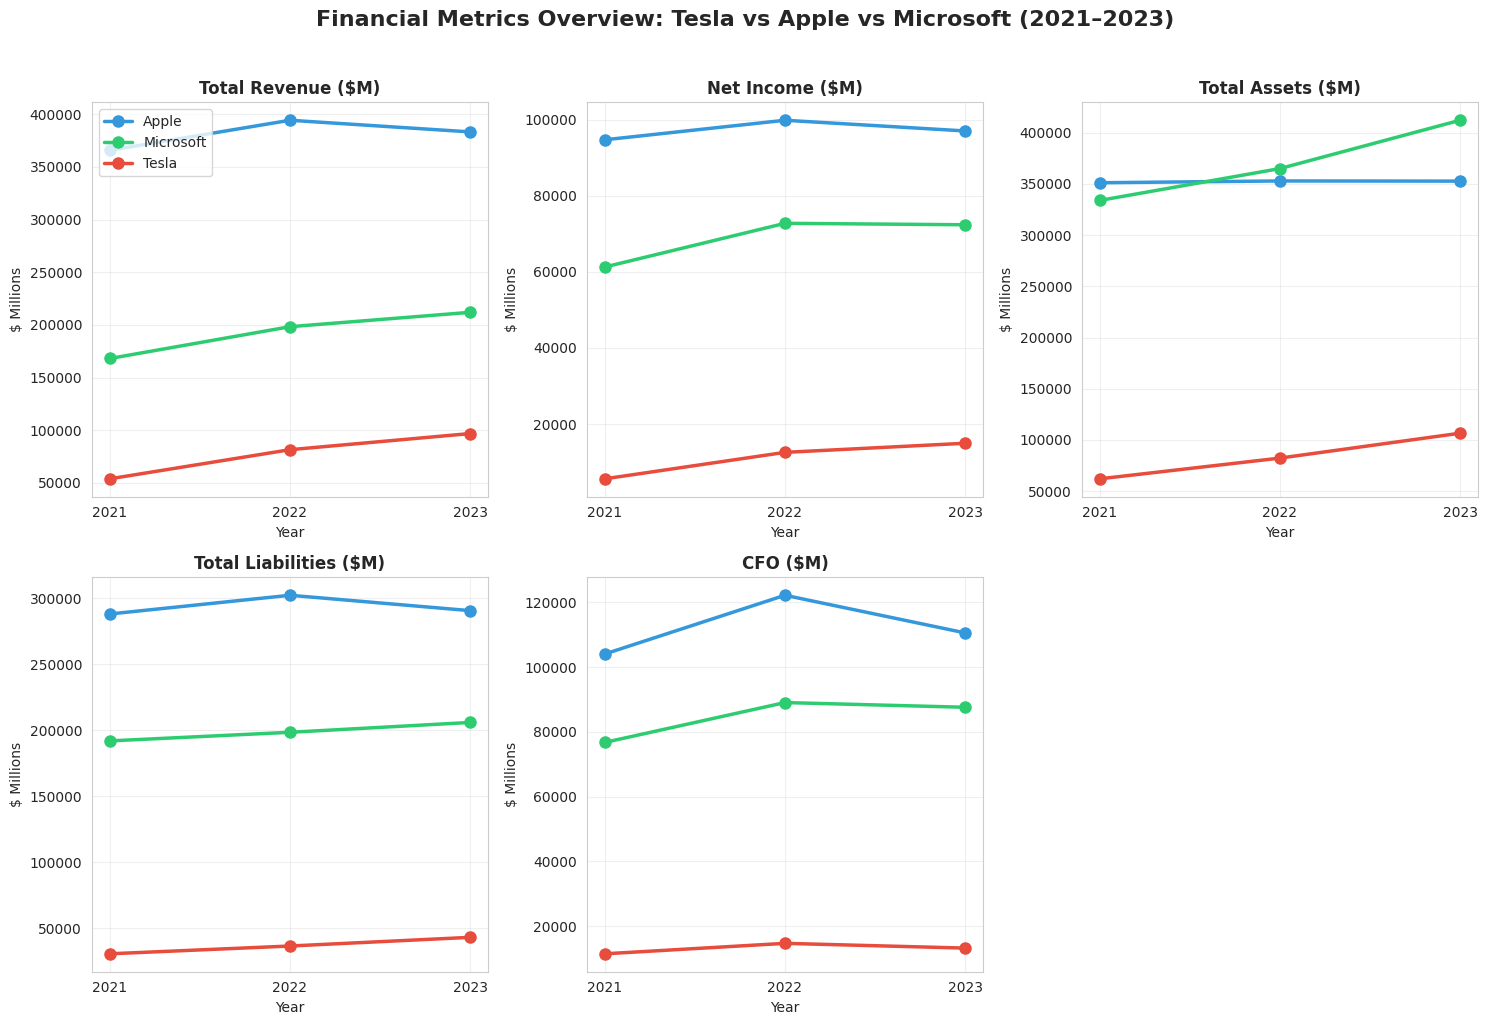

In [ ]:
metrics = [
    ('Total Revenue', 'Total Revenue ($M)'),
    ('Net Income', 'Net Income ($M)'),
    ('Total Assets', 'Total Assets ($M)'),
    ('Total Liabilities', 'Total Liabilities ($M)'),
    ('Cash Flow from Operations', 'CFO ($M)')
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 rows, 3 cols (last one empty)
axes = axes.flatten()  # Flatten to 1D list

colors = {'Tesla': '#e74c3c', 'Apple': '#3498db', 'Microsoft': '#2ecc71'}

for idx, (col, label) in enumerate(metrics):
    ax = axes[idx]

    for company in df['Company'].unique():
        subset = df[df['Company'] == company]
        ax.plot(subset['Year'], subset[col],
                marker='o', linewidth=2.5, markersize=8,
                label=company, color=colors[company])

    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('$ Millions')
    ax.set_xticks([2021, 2022, 2023])
    ax.grid(True, alpha=0.3)

    # Only show legend on first subplot
    if idx == 0:
        ax.legend(loc='upper left')

# Hide the empty 6th subplot
axes[5].set_visible(False)

plt.suptitle('Financial Metrics Overview: Tesla vs Apple vs Microsoft (2021–2023)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
growth_cols = ['Revenue Growth (%)', 'Net Income Growth (%)',
               'Assets Growth (%)', 'Liabilities Growth (%)', 'Cash Flow Growth (%)']

summary = df[df['Year'] != 2021].groupby('Company')[growth_cols].mean().round(2)

print("=== AVERAGE YoY GROWTH RATES (2022–2023) ===")
print(summary)
print()

# CAGR (Compound Annual Growth Rate)
# Formula: (End/Start)^(1/years) - 1
def calc_cagr(start, end, years=2):
    return ((end / start) ** (1/years) - 1) * 100

cagr_data = []
for company in df['Company'].unique():
    sub = df[df['Company'] == company].sort_values('Year')
    cagr_data.append({
        'Company': company,
        'Revenue CAGR (%)': round(calc_cagr(sub['Total Revenue'].iloc[0], sub['Total Revenue'].iloc[-1]), 2),
        'Net Income CAGR (%)': round(calc_cagr(sub['Net Income'].iloc[0], sub['Net Income'].iloc[-1]), 2),
        'Assets CAGR (%)': round(calc_cagr(sub['Total Assets'].iloc[0], sub['Total Assets'].iloc[-1]), 2)
    })

df_cagr = pd.DataFrame(cagr_data)
print("=== 2-YEAR CAGR (2021→2023) ===")
print(df_cagr)
print()

# Key observations
print("=== KEY OBSERVATIONS ===")
print(f"Tesla: Fastest growth but CFO declined {df[(df['Company']=='Tesla')&(df['Year']==2023)]['Cash Flow Growth (%)'].values[0]:.1f}% in 2023")
print(f"Apple: Revenue declined in 2023 by {df[(df['Company']=='Apple')&(df['Year']==2023)]['Revenue Growth (%)'].values[0]:.1f}%")
print(f"Microsoft: Steady double-digit revenue growth through 2022, slowing to {df[(df['Company']=='Microsoft')&(df['Year']==2023)]['Revenue Growth (%)'].values[0]:.1f}% in 2023")


=== AVERAGE YoY GROWTH RATES (2022–2023) ===
           Revenue Growth (%)  Net Income Growth (%)  Assets Growth (%)  \
Company                                                                   
Apple                    2.50                   1.30               0.23   
Microsoft               12.42                   9.10              11.11   
Tesla                   35.07                  70.99              31.01   

           Liabilities Growth (%)  Cash Flow Growth (%)  
Company                                                  
Apple                        0.53                  3.95  
Microsoft                    3.58                  7.19  
Tesla                       18.66                  9.05  

=== 2-YEAR CAGR (2021→2023) ===
     Company  Revenue CAGR (%)  Net Income CAGR (%)  Assets CAGR (%)
0      Apple              2.36                 1.22             0.22
1  Microsoft             12.28                 8.67            11.10
2      Tesla             34.09                62.

In [ ]:
with pd.ExcelWriter('BCG_Task1_Final_Analysis.xlsx', engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Full Data', index=False)
    summary.to_excel(writer, sheet_name='Avg Growth Rates')
    df_cagr.to_excel(writer, sheet_name='CAGR', index=False)

print("\n✅ Exported to 'BCG_Task1_Final_Analysis.xlsx'")


✅ Exported to 'BCG_Task1_Final_Analysis.xlsx'


In [ ]:
"""TASK 2"""

import pandas as pd

print(df[(df['Company'] == 'Tesla') & (df['Year'] == 2023)]['Total Revenue'].values[0])

96773.0


In [ ]:
def parse_question(question):
    question = question.lower()

    # ========== 1. DETECT COMPANY ==========
    company = None
    if 'tesla' in question:
        company = 'Tesla'
    elif 'apple' in question:
        company = 'Apple'
    elif 'microsoft' in question:
        company = 'Microsoft'
    elif 'company' in question:
        company = 'all'
    # ========== 2. DETECT METRIC ==========
    metric = None
    if any(word in question for word in ['revenue', 'sales', 'total revenue']):
        metric = 'Total Revenue'
    elif any(word in question for word in ['net income', 'profit', 'earnings']):
        metric = 'Net Income'
    elif any(word in question for word in ['assets', 'total assets']):
        metric = 'Total Assets'
    elif any(word in question for word in ['liabilities', 'debt', 'total liabilities']):
        metric = 'Total Liabilities'
    elif any(word in question for word in ['cash flow', 'cfo', 'operating cash']):
        metric = 'Cash Flow from Operations'

    # ========== 3. DETECT YEAR ==========
    year = 'latest'
    if '2021' in question:
        year = 2021
    elif '2022' in question:
        year = 2022
    elif '2023' in question:
        year = 2023

    # ========== 4. DETECT QUERY TYPE + PERCENTAGE FLAG ==========
    query_type = 'value'
    want_percentage = False  # NEW!

    # Percentage/growth questions
    if any(word in question for word in ['percent', 'percentage', '%', 'growth rate',
                                          'how much did', 'increase by', 'decrease by',
                                          'what percent', 'by how much']):
        want_percentage = True
        query_type = 'trend'

    # Comparison questions
    elif any(word in question for word in ['highest', 'lowest', 'most', 'least',
                                            'biggest', 'smallest', 'compare', 'vs']):
        query_type = 'comparison'

    # Trend questions (without explicit %)
    elif any(word in question for word in ['change', 'changed', 'growth', 'trend',
                                            'over time', 'history']):
        query_type = 'trend'

    return {
        'company': company,
        'metric': metric,
        'year': year,
        'query_type': query_type,
        'want_percentage': want_percentage  # NEW!
    }


# ========== TEST WITH PERCENTAGE QUESTIONS ==========
test_questions = [
    "What is Tesla's revenue in 2023?",
    "How much did Tesla's revenue grow in 2022?",           # trend, no %
    "What percentage did Tesla's revenue grow in 2022?",    # trend + %
    "By what percent did Apple's net income change?",       # trend + %
    "Which company has the highest net income?"
]

for q in test_questions:
    result = parse_question(q)
    print(f"Q: {q}")
    print(f"   → {result}\n")

Q: What is Tesla's revenue in 2023?
   → {'company': 'Tesla', 'metric': 'Total Revenue', 'year': 2023, 'query_type': 'value', 'want_percentage': False}

Q: How much did Tesla's revenue grow in 2022?
   → {'company': 'Tesla', 'metric': 'Total Revenue', 'year': 2022, 'query_type': 'trend', 'want_percentage': True}

Q: What percentage did Tesla's revenue grow in 2022?
   → {'company': 'Tesla', 'metric': 'Total Revenue', 'year': 2022, 'query_type': 'trend', 'want_percentage': True}

Q: By what percent did Apple's net income change?
   → {'company': 'Apple', 'metric': 'Net Income', 'year': 'latest', 'query_type': 'trend', 'want_percentage': True}

Q: Which company has the highest net income?
   → {'company': 'all', 'metric': 'Net Income', 'year': 'latest', 'query_type': 'comparison', 'want_percentage': False}



In [ ]:
def generate_response(parsed, df):
    company = parsed['company']
    metric = parsed['metric']
    year = parsed['year']
    query_type = parsed['query_type']
    want_percentage = parsed['want_percentage']

    # ========== ERROR HANDLING ==========
    if metric is None:
        return "Sorry, I didn't understand which metric you're asking about. Try: revenue, net income, assets, liabilities, or cash flow."

    if company is None:
        return "Sorry, I only have data for Tesla, Apple, and Microsoft. I don't have information about that company."

    if year == 'latest':
        year = df['Year'].max()

    # ============================================
    # TYPE 1: SIMPLE VALUE
    # ============================================
    if query_type == 'value':
        value = df[(df['Company'] == company) & (df['Year'] == year)][metric].values[0]
        return f"{company}'s {metric} in {year} was ${value:,.0f} million."

    # ============================================
    # TYPE 2: COMPARISON
    # ============================================
    elif query_type == 'comparison':
        latest_df = df[df['Year'] == year]
        max_idx = latest_df[metric].idxmax()
        winner = latest_df.loc[max_idx, 'Company']
        winner_val = latest_df.loc[max_idx, metric]
        return f"{winner} has the highest {metric.lower()} in {year} at ${winner_val:,.0f} million."

    # ============================================
    # TYPE 3: TREND
    # ============================================
    elif query_type == 'trend':
        company_df = df[df['Company'] == company].sort_values('Year')

        # Safety check: did we find the company?
        if company_df.empty:
            return f"Sorry, I don't have data for {company}."

        years = company_df['Year'].tolist()
        values = company_df[metric].tolist()

        changes = []
        for i in range(1, len(values)):
            prev = values[i-1]
            curr = values[i]
            abs_change = curr - prev
            pct_change = ((curr - prev) / prev) * 100
            changes.append({
                'from_year': years[i-1],
                'to_year': years[i],
                'abs_change': abs_change,
                'pct_change': pct_change
            })

        if want_percentage:
            response = f"{company}'s {metric} growth:\n"
            for c in changes:
                direction = "increased" if c['pct_change'] > 0 else "decreased"
                response += f"  • {c['from_year']} → {c['to_year']}: {direction} by {abs(c['pct_change']):.1f}%\n"
            return response
        else:
            response = f"{company}'s {metric} over time:\n"
            for c in changes:
                direction = "increased" if c['abs_change'] > 0 else "decreased"
                response += f"  • {c['from_year']} → {c['to_year']}: {direction} by ${abs(c['abs_change']):,.0f}M ({c['pct_change']:+.1f}%)\n"
            return response

In [ ]:
def chatbot():
    print("=" * 55)
    print("🤖  BCG FINANCIAL CHATBOT")
    print("=" * 55)
    print("Ask me anything about Tesla, Apple, or Microsoft!")
    print("Examples:")
    print('  • "What is Tesla revenue in 2023?"')
    print('  • "How much did Apple net income grow?"')
    print('  • "What percentage did Microsoft cash flow change?"')
    print('  • "Which company has the highest assets?"')
    print('  • Type "bye" to exit\n')

    while True:
        # Get user input
        question = input("👤 You: ").strip()

        # Exit condition
        if question.lower() in ['bye', 'exit', 'quit', 'q']:
            print("🤖 Bot: Thanks for chatting! Good luck with your BCG submission. 🚀")
            break

        # Skip empty input
        if not question:
            continue

        # Parse + Respond
        parsed = parse_question(question)

        # Handle missing info gracefully
        if parsed['metric'] is None:
            print("🤖 Bot: Sorry, I didn't understand which metric you're asking about.")
            print("         Try: revenue, net income, assets, liabilities, or cash flow.")
            continue

        response = generate_response(parsed, df)
        print(f"🤖 Bot: {response}\n")


# ========== RUN IT ==========
chatbot()

🤖  BCG FINANCIAL CHATBOT
Ask me anything about Tesla, Apple, or Microsoft!
Examples:
  • "What is Tesla revenue in 2023?"
  • "How much did Apple net income grow?"
  • "What percentage did Microsoft cash flow change?"
  • "Which company has the highest assets?"
  • Type "bye" to exit

👤 You: Which company has the highest assets
🤖 Bot: Microsoft has the highest total assets in 2023 at $411,976 million.

👤 You: How much did Apple net income grow
🤖 Bot: Apple's Net Income growth:
  • 2021 → 2022: increased by 5.4%
  • 2022 → 2023: decreased by 2.8%


👤 You: How much did google net income grow
🤖 Bot: Sorry, I only have data for Tesla, Apple, and Microsoft. I don't have information about that company.

👤 You: revenue revenue
🤖 Bot: Sorry, I only have data for Tesla, Apple, and Microsoft. I don't have information about that company.

👤 You: which highest cash flow 
🤖 Bot: Sorry, I only have data for Tesla, Apple, and Microsoft. I don't have information about that company.

👤 You: What percen

The chat bot works completely fine with accurate answers according to original documents.
the only drawback that we can see now is that it works only of the perfect structured questions but not on different ones.